In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
(50000, 32, 32, 3)


In [ ]:
#import lib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam


In [ ]:
#preprocess
# Normalize images (0–255 → 0–1)
x_train = x_train / 255.0
x_test  = x_test / 255.0


In [ ]:
model = Sequential()

# First convolution layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)))
model.add(MaxPooling2D((2,2)))

# Second convolution layer
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

# Flatten for fully connected layer
model.add(Flatten())

# Dense layer
model.add(Dense(64, activation='relu'))

# Output layer (10 CIFAR classes)
model.add(Dense(10, activation='softmax'))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
#adam optiimiser
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=5,          # Keep LOW to save time
    batch_size=64,     # Larger batch = faster
    validation_split=0.1
)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.3603 - loss: 1.7551 - val_accuracy: 0.5428 - val_loss: 1.2688
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.5645 - loss: 1.2256 - val_accuracy: 0.6102 - val_loss: 1.1276
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6208 - loss: 1.0763 - val_accuracy: 0.6240 - val_loss: 1.0721
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6601 - loss: 0.9743 - val_accuracy: 0.6678 - val_loss: 0.9707
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6803 - loss: 0.9144 - val_accuracy: 0.6812 - val_loss: 0.9396


In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test accuracy:", test_acc)


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6720 - loss: 0.9446
Test accuracy: 0.6656000018119812


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#zselecting test image
# Take one image from test set
index = 5
image = x_test[index:index+1]   # shape (1,32,32,3)
label = y_test[index]


In [ ]:
pred = model.predict(image)
original_label = np.argmax(pred)

print("Original prediction:", class_names[original_label])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 555ms/step
Original prediction: frog


In [ ]:
def fgsm_attack(model, image, label, epsilon=0.02):
    image = tf.convert_to_tensor(image)

    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = model(image)
        loss = tf.keras.losses.sparse_categorical_crossentropy(label, prediction)

    # Get gradients
    gradient = tape.gradient(loss, image)

    # Create adversarial image
    signed_grad = tf.sign(gradient)
    adv_image = image + epsilon * signed_grad
    adv_image = tf.clip_by_value(adv_image, 0, 1)

    return adv_image


In [ ]:
# 1️⃣ Generate FGSM adversarial image
adv_fgsm = fgsm_attack(model, image, label)

# 2️⃣ Get prediction on adversarial image
fgsm_pred = model.predict(adv_fgsm)
fgsm_label = np.argmax(fgsm_pred)   # <- this defines fgsm_label

# 3️⃣ Map to robot action
robot_action_adv = actions[fgsm_label % 4]
print("Robot after adversarial attack would:", robot_action_adv)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Robot after adversarial attack would: ignore


In [ ]:
def pgd_attack(model, image, label, epsilon=0.03, alpha=0.005, iters=10):
    adv_image = tf.identity(image)

    for i in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(adv_image)
            prediction = model(adv_image)
            loss = tf.keras.losses.sparse_categorical_crossentropy(label, prediction)

        gradient = tape.gradient(loss, adv_image)
        adv_image = adv_image + alpha * tf.sign(gradient)

        # Keep perturbation small
        adv_image = tf.clip_by_value(adv_image, image - epsilon, image + epsilon)
        adv_image = tf.clip_by_value(adv_image, 0, 1)

    return adv_image


In [ ]:
adv_pgd = pgd_attack(model, image, label)
pgd_pred = model.predict(adv_pgd)
pgd_label = np.argmax(pgd_pred)

robot_action_adv_pgd = actions[pgd_label % 4]
print("Robot after PGD attack would:", robot_action_adv_pgd)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Robot after PGD attack would: move


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

found = False

for idx in range(0, 10000):
    img = x_test[idx:idx+1]
    label = y_test[idx][0]

    pred = np.argmax(model.predict(img))

    # ROBOTIC DECISION CONDITION
    if pred == label:
        index = idx
        found = True
        break

if not found:
    print("No valid image found")
else:
    print("Selected index:", index)
    print("True label:", class_names[label])
    print("Original prediction:", class_names[pred])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
Selected index: 1
True label: ship
Original prediction: ship


In [ ]:
# FGSM
adv_fgsm = fgsm_attack(model, img, y_test[index:index+1], epsilon=0.005)
fgsm_pred = np.argmax(model.predict(adv_fgsm))

# PGD
adv_pgd = pgd_attack(model, img, y_test[index:index+1],
                     epsilon=0.03, alpha=0.005, iters=15)
pgd_pred = np.argmax(model.predict(adv_pgd))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


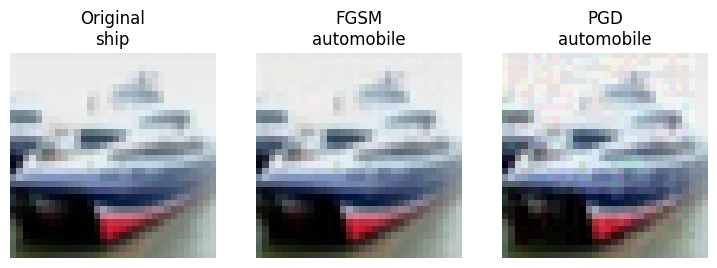

In [ ]:
plt.figure(figsize=(9,3))

plt.subplot(1,3,1)
plt.imshow(img[0])
plt.title("Original\n" + class_names[pred])
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(adv_fgsm[0])
plt.title("FGSM\n" + class_names[fgsm_pred])
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(adv_pgd[0])
plt.title("PGD\n" + class_names[pgd_pred])
plt.axis("off")

plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Find a test image where model is WRONG
for idx in range(0, 10000):
    img = x_test[idx:idx+1]
    true_label = y_test[idx][0]
    pred = np.argmax(model.predict(img))

    if pred != true_label:
        index = idx
        break

print("Selected index:", index)
print("True label:", class_names[true_label])
print("Model prediction:", class_names[pred])
print("Decision: STOP (no FGSM / PGD applied)")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Selected index: 0
True label: cat
Model prediction: ship
Decision: STOP (no FGSM / PGD applied)


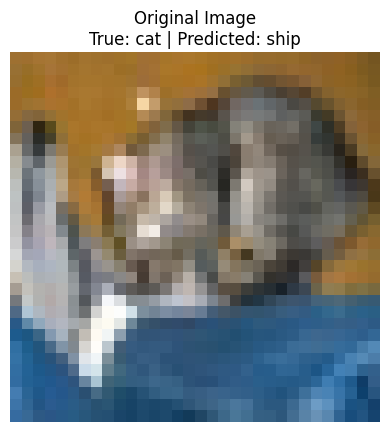

In [ ]:
plt.imshow(img[0])
plt.title("Original Image\nTrue: " + class_names[true_label] +
          " | Predicted: " + class_names[pred])
plt.axis("off")
plt.show()


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

# Generator: generates small adversarial noise
def build_generator():
    model = tf.keras.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.Conv2D(3, 3, padding="same", activation="tanh")  # noise
    ])
    return model

# Discriminator: checks if image is real or adversarial
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32, 3, activation="relu"),
        layers.Flatten(),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()


In [ ]:
loss_fn = tf.keras.losses.BinaryCrossentropy()
g_opt = tf.keras.optimizers.Adam(1e-4)
d_opt = tf.keras.optimizers.Adam(1e-4)

@tf.function
def train_step(images):
    batch_size = tf.shape(images)[0]

    # Train discriminator
    noise = generator(images, training=True)
    adv_images = tf.clip_by_value(images + 0.03 * noise, 0, 1)

    real_labels = tf.ones((batch_size,1))
    fake_labels = tf.zeros((batch_size,1))

    with tf.GradientTape() as tape:
        real_pred = discriminator(images, training=True)
        fake_pred = discriminator(adv_images, training=True)
        d_loss = loss_fn(real_labels, real_pred) + loss_fn(fake_labels, fake_pred)

    grads = tape.gradient(d_loss, discriminator.trainable_variables)
    d_opt.apply_gradients(zip(grads, discriminator.trainable_variables))

    # Train generator
    with tf.GradientTape() as tape:
        noise = generator(images, training=True)
        adv_images = tf.clip_by_value(images + 0.03 * noise, 0, 1)
        fake_pred = discriminator(adv_images, training=True)
        g_loss = loss_fn(real_labels, fake_pred)

    grads = tape.gradient(g_loss, generator.trainable_variables)
    g_opt.apply_gradients(zip(grads, generator.trainable_variables))


In [ ]:
def hybrid_gan_pgd(model, image, label, generator, epsilon=0.03, alpha=0.005, iters=5):
    # Step 1: GAN noise
    noise = generator(image)
    adv = tf.clip_by_value(image + epsilon * noise, 0, 1)

    # Step 2: PGD refinement
    for _ in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(adv)
            pred = model(adv)
            loss = tf.keras.losses.sparse_categorical_crossentropy(label, pred)

        grad = tape.gradient(loss, adv)
        adv = adv + alpha * tf.sign(grad)
        adv = tf.clip_by_value(adv, image - epsilon, image + epsilon)
        adv = tf.clip_by_value(adv, 0, 1)

    return adv


In [ ]:
class_names = ['airplane','auto','bird','cat','deer','dog','frog','horse','ship','truck']

test_ids = [5, 12, 25, 40]   # 4 different examples

for idx in test_ids:
    img = x_test[idx:idx+1]
    label = y_test[idx]

    clean_pred = tf.argmax(model(img), axis=1)[0]

    # Skip if model already wrong
    if clean_pred != label:
        print(f"Skipping image {idx} (model already wrong)")
        continue

    fgsm_img = fgsm_attack(model, img, label)
    pgd_img  = pgd_attack(model, img, label)

    gan_noise = generator(img)
    gan_img = tf.clip_by_value(img + 0.03 * gan_noise, 0, 1)

    hybrid_img = hybrid_gan_pgd(model, img, label, generator)

    print(f"\nImage {idx}")
    print("True label :", class_names[label[0]])
    print("Clean pred :", class_names[clean_pred.numpy()])
    print("FGSM pred  :", class_names[tf.argmax(model(fgsm_img),1)[0]])
    print("PGD pred   :", class_names[tf.argmax(model(pgd_img),1)[0]])
    print("GAN pred   :", class_names[tf.argmax(model(gan_img),1)[0]])
    print("Hybrid pred:", class_names[tf.argmax(model(hybrid_img),1)[0]])



Image 5
True label : frog
Clean pred : frog
FGSM pred  : dog
PGD pred   : horse
GAN pred   : frog
Hybrid pred: horse

Image 12
True label : dog
Clean pred : dog
FGSM pred  : deer
PGD pred   : deer
GAN pred   : dog
Hybrid pred: deer

Image 25
True label : bird
Clean pred : bird
FGSM pred  : dog
PGD pred   : frog
GAN pred   : bird
Hybrid pred: frog
Skipping image 40 (model already wrong)


In [ ]:
class_names = ['airplane','auto','bird','cat','deer',
               'dog','frog','horse','ship','truck']

found = False

for i in range(1000):   # check first 1000 test images
    img = x_test[i:i+1]
    label = y_test[i]

    # Clean prediction
    clean_pred = tf.argmax(model(img), axis=1)[0]

    # Only consider correctly classified images
    if clean_pred != label:
        continue

    # FGSM & PGD
    fgsm_img = fgsm_attack(model, img, label, epsilon=0.01)
    pgd_img  = pgd_attack(model, img, label, epsilon=0.03, alpha=0.005, iters=10)

    fgsm_pred = tf.argmax(model(fgsm_img), axis=1)[0]
    pgd_pred  = tf.argmax(model(pgd_img), axis=1)[0]

    # FGSM fails, PGD succeeds
    if fgsm_pred == clean_pred and pgd_pred != clean_pred:
        print("FOUND EXAMPLE")
        print("Image index :", i)
        print("True label :", class_names[label[0]])
        print("Original   :", class_names[clean_pred.numpy()])
        print("FGSM pred  :", class_names[fgsm_pred.numpy()])
        print("PGD pred   :", class_names[pgd_pred.numpy()])

        found = True
        break

if not found:
    print("No example found in this range — increase range or epsilon")


FOUND EXAMPLE
Image index : 9
True label : auto
Original   : auto
FGSM pred  : auto
PGD pred   : truck


In [ ]:
import matplotlib.pyplot as plt

def show_images(images, titles):
    plt.figure(figsize=(12,3))
    for i, img in enumerate(images):
        plt.subplot(1, len(images), i+1)
        plt.imshow(img)
        plt.title(titles[i])
        plt.axis("off")
    plt.show()


FGSM FAILED, PGD SUCCEEDED


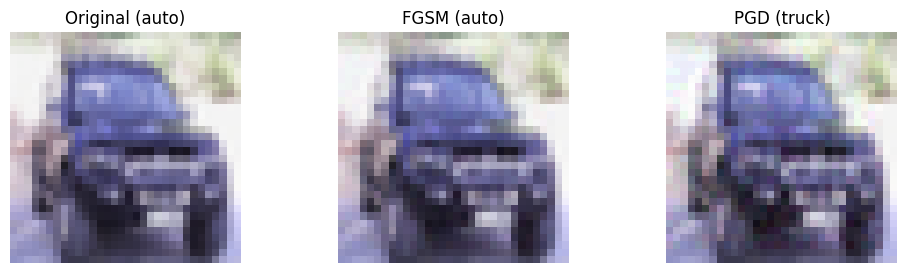

In [ ]:
for i in range(1000):
    img = x_test[i:i+1]
    label = y_test[i]

    clean_pred = tf.argmax(model(img), axis=1)[0]

    if clean_pred != label:
        continue

    fgsm_img = fgsm_attack(model, img, label, epsilon=0.01)
    pgd_img  = pgd_attack(model, img, label, epsilon=0.03, alpha=0.005, iters=10)

    fgsm_pred = tf.argmax(model(fgsm_img), axis=1)[0]
    pgd_pred  = tf.argmax(model(pgd_img), axis=1)[0]

    if fgsm_pred == clean_pred and pgd_pred != clean_pred:
        print("FGSM FAILED, PGD SUCCEEDED")

        show_images(
            [img[0], fgsm_img[0], pgd_img[0]],
            [
                f"Original ({class_names[clean_pred]})",
                f"FGSM ({class_names[fgsm_pred]})",
                f"PGD ({class_names[pgd_pred]})"
            ]
        )
        break


In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense


In [ ]:
# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train/255.0, x_test/255.0

class_names = ['airplane','auto','bird','cat','deer',
               'dog','frog','horse','ship','truck']


In [ ]:
model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.fit(x_train,y_train,epochs=5,batch_size=64,validation_split=0.1)


Epoch 1/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.3290 - loss: 1.8380 - val_accuracy: 0.5384 - val_loss: 1.3315
Epoch 2/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5390 - loss: 1.3134 - val_accuracy: 0.5808 - val_loss: 1.1923
Epoch 3/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.5952 - loss: 1.1470 - val_accuracy: 0.5852 - val_loss: 1.1486
Epoch 4/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.6359 - loss: 1.0522 - val_accuracy: 0.5994 - val_loss: 1.1073
Epoch 5/5
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6570 - loss: 0.9757 - val_accuracy: 0.6572 - val_loss: 1.0006


In [ ]:
def fgsm_attack(model, image, label, epsilon=0.01):
    image = tf.convert_to_tensor(image)
    with tf.GradientTape() as tape:
        tape.watch(image)
        pred = model(image)
        loss = tf.keras.losses.sparse_categorical_crossentropy(label, pred)
    grad = tape.gradient(loss, image)
    adv = image + epsilon * tf.sign(grad)
    return tf.clip_by_value(adv, 0, 1)


In [ ]:
def pgd_attack(model, image, label, epsilon=0.03, alpha=0.005, iters=10):
    adv = tf.identity(image)
    for _ in range(iters):
        with tf.GradientTape() as tape:
            tape.watch(adv)
            pred = model(adv)
            loss = tf.keras.losses.sparse_categorical_crossentropy(label, pred)
        grad = tape.gradient(loss, adv)
        adv = adv + alpha * tf.sign(grad)
        adv = tf.clip_by_value(adv, image-epsilon, image+epsilon)
        adv = tf.clip_by_value(adv, 0, 1)
    return adv


In [ ]:
def build_generator():
    return tf.keras.Sequential([
        Conv2D(32,3,padding='same',activation='relu',input_shape=(32,32,3)),
        Conv2D(3,3,padding='same',activation='tanh')
    ])

generator = build_generator()


In [ ]:
def gan_attack(image, epsilon=0.03):
    noise = generator(image)
    return tf.clip_by_value(image + epsilon*noise, 0, 1)


In [ ]:
def hybrid_attack(model, image, label):
    adv = gan_attack(image)
    adv = pgd_attack(model, adv, label, iters=5)
    return adv


In [ ]:
def show(images, titles):
    plt.figure(figsize=(12,3))
    for i in range(len(images)):
        plt.subplot(1,len(images),i+1)
        plt.imshow(images[i])
        plt.title(titles[i])
        plt.axis('off')
    plt.show()


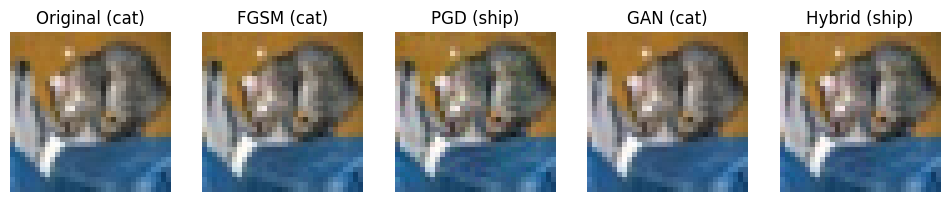

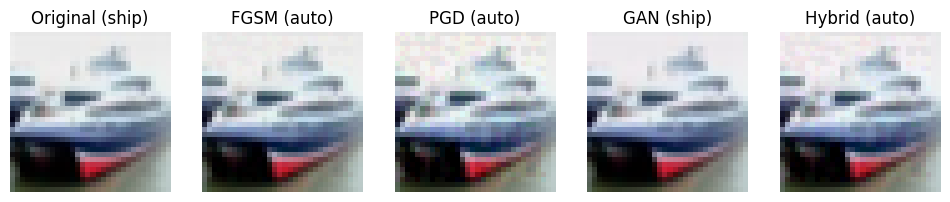

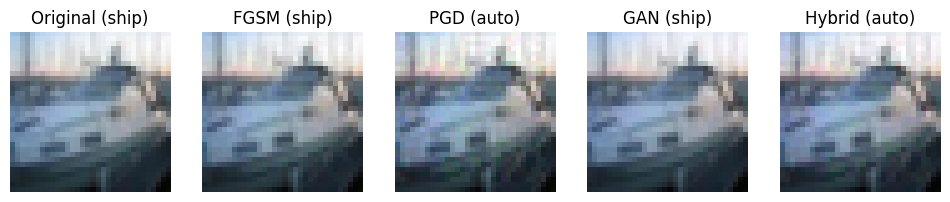

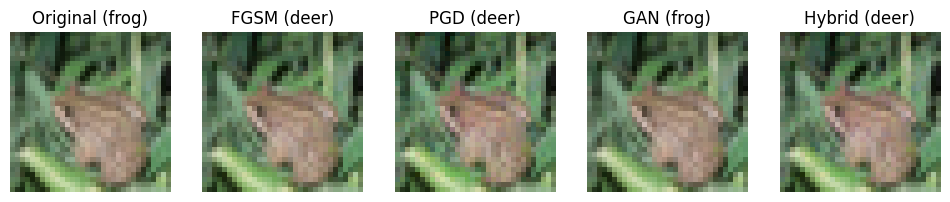

In [ ]:
count = 0
for i in range(1000):
    img = x_test[i:i+1]
    label = y_test[i]

    clean_pred = tf.argmax(model(img),1)[0]
    if clean_pred != label:   # robotics rule
        continue

    fgsm_img = fgsm_attack(model,img,label)
    pgd_img  = pgd_attack(model,img,label)
    gan_img  = gan_attack(img)
    hyb_img  = hybrid_attack(model,img,label)

    show(
        [img[0], fgsm_img[0], pgd_img[0], gan_img[0], hyb_img[0]],
        [
            f"Original ({class_names[clean_pred]})",
            f"FGSM ({class_names[tf.argmax(model(fgsm_img),1)[0]]})",
            f"PGD ({class_names[tf.argmax(model(pgd_img),1)[0]]})",
            f"GAN ({class_names[tf.argmax(model(gan_img),1)[0]]})",
            f"Hybrid ({class_names[tf.argmax(model(hyb_img),1)[0]]})"
        ]
    )

    count += 1
    if count == 4:
        break


In [ ]:
# Install required library (if needed)
!pip install torch torchvision matplotlib --quiet

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                         download=True, transform=transform)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128,
                                          shuffle=True)

testloader = torch.utils.data.DataLoader(testset, batch_size=128,
                                         shuffle=False)

100%|██████████| 170M/170M [00:04<00:00, 35.7MB/s]


In [ ]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(64 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(-1, 64 * 8 * 8)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CNN().to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

for epoch in range(epochs):
    model.train()
    running_loss = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {running_loss/len(trainloader)}")

Epoch 1, Loss: 1.5324392651048158
Epoch 2, Loss: 1.1828525308757791
Epoch 3, Loss: 1.0294109043257926
Epoch 4, Loss: 0.9361959950393423
Epoch 5, Loss: 0.8576568650162738


In [ ]:
def evaluate(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total

clean_acc = evaluate(model, testloader)
print("Clean Accuracy:", clean_acc)

Clean Accuracy: 68.0


In [ ]:
def fgsm_attack(model, images, labels, epsilon):
    images.requires_grad = True
    outputs = model(images)
    loss = criterion(outputs, labels)
    model.zero_grad()
    loss.backward()
    data_grad = images.grad.data
    perturbed_images = images + epsilon * data_grad.sign()
    perturbed_images = torch.clamp(perturbed_images, 0, 1)
    return perturbed_images

In [ ]:
def evaluate_fgsm(model, loader, epsilon):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        perturbed = fgsm_attack(model, images, labels, epsilon)
        outputs = model(perturbed)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return 100 * correct / total

fgsm_acc = evaluate_fgsm(model, testloader, epsilon=0.03)
print("FGSM Accuracy:", fgsm_acc)

FGSM Accuracy: 2.79


In [ ]:
def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.01, iters=10):
    original_images = images.clone().detach()

    for i in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()
        images = images + alpha * images.grad.sign()
        eta = torch.clamp(images - original_images, min=-epsilon, max=epsilon)
        images = torch.clamp(original_images + eta, 0, 1).detach()

    return images

In [ ]:
def evaluate_pgd(model, loader):
    model.eval()
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        perturbed = pgd_attack(model, images, labels)
        outputs = model(perturbed)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    return 100 * correct / total

pgd_acc = evaluate_pgd(model, testloader)
print("PGD Accuracy:", pgd_acc)

PGD Accuracy: 0.36


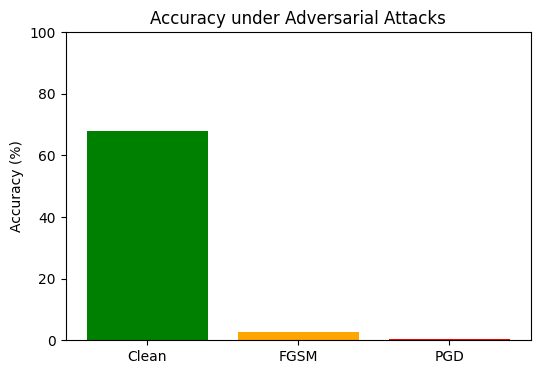

In [ ]:
attacks = ['Clean', 'FGSM', 'PGD']
accuracies = [clean_acc, fgsm_acc, pgd_acc]

plt.figure(figsize=(6,4))
plt.bar(attacks, accuracies, color=['green','orange','red'])
plt.ylabel("Accuracy (%)")
plt.title("Accuracy under Adversarial Attacks")
plt.ylim(0,100)
plt.show()

In [ ]:
def gan_attack(images, epsilon=0.03):

    noise = torch.randn_like(images) * epsilon
    adv_images = images + noise
    adv_images = torch.clamp(adv_images,0,1)

    return adv_images

In [ ]:
def hybrid_attack(model,images,labels):

    images = gan_attack(images)

    images = pgd_attack(model,images,labels)

    return images

In [ ]:
def evaluate(loader, attack=None):

    correct=0
    total=0

    for images,labels in loader:

        images,labels = images.to(device),labels.to(device)

        if attack=="fgsm":

            images.requires_grad=True
            outputs=model(images)
            loss=criterion(outputs,labels)

            model.zero_grad()
            loss.backward()

            images = fgsm_attack(images,0.03,images.grad)

        elif attack=="pgd":

            images = pgd_attack(model,images,labels)

        elif attack=="gan":

            images = gan_attack(images)

        elif attack=="hybrid":

            images = hybrid_attack(model,images,labels)

        outputs = model(images)
        _,predicted = torch.max(outputs.data,1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()

    return 100*correct/total

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# CIFAR10 dataset
transform = transforms.Compose([transforms.ToTensor()])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=False)

# CNN MODEL
class CNN(nn.Module):
    def __init__(self):
        super(CNN,self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3,32,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*8*8,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )

    def forward(self,x):
        x=self.conv(x)
        x=self.fc(x)
        return x

model = CNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

# TRAIN MODEL
for epoch in range(3):
    for images,labels in trainloader:

        images,labels = images.to(device),labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)

        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()

print("Training Done")

Training Done


In [ ]:
def fgsm_attack(image, epsilon, data_grad):

    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon*sign_data_grad
    perturbed_image = torch.clamp(perturbed_image,0,1)

    return perturbed_image

In [ ]:
def pgd_attack(model, images, labels, eps=0.03, alpha=0.01, iters=10):

    ori_images = images.data

    for i in range(iters):

        images.requires_grad = True
        outputs = model(images)

        model.zero_grad()
        loss = criterion(outputs, labels)
        loss.backward()

        adv_images = images + alpha*images.grad.sign()

        eta = torch.clamp(adv_images - ori_images, min=-eps, max=eps)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach()

    return images

In [ ]:
clean_acc = evaluate(testloader,None)
fgsm_acc = evaluate(testloader,"fgsm")
pgd_acc = evaluate(testloader,"pgd")
gan_acc = evaluate(testloader,"gan")
hybrid_acc = evaluate(testloader,"hybrid")

print(clean_acc, fgsm_acc, pgd_acc, gan_acc, hybrid_acc)

66.19 4.91 1.0 64.85 0.72


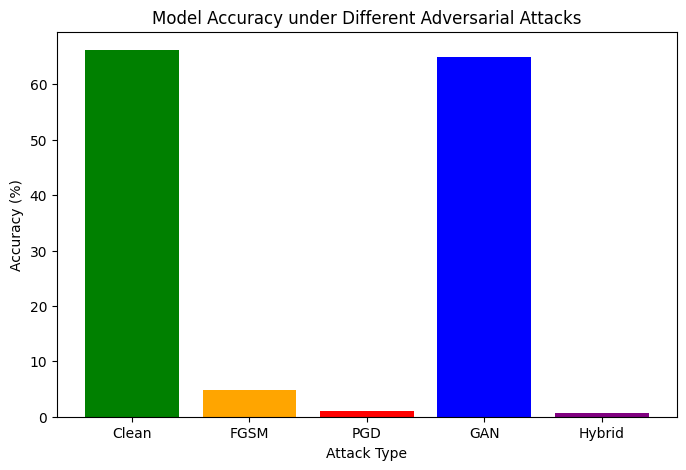

In [ ]:
attacks = ['Clean','FGSM','PGD','GAN','Hybrid']

accuracy = [clean_acc,fgsm_acc,pgd_acc,gan_acc,hybrid_acc]

plt.figure(figsize=(8,5))
plt.bar(attacks,accuracy,color=['green','orange','red','blue','purple'])

plt.xlabel("Attack Type")
plt.ylabel("Accuracy (%)")
plt.title("Model Accuracy under Different Adversarial Attacks")

plt.show()

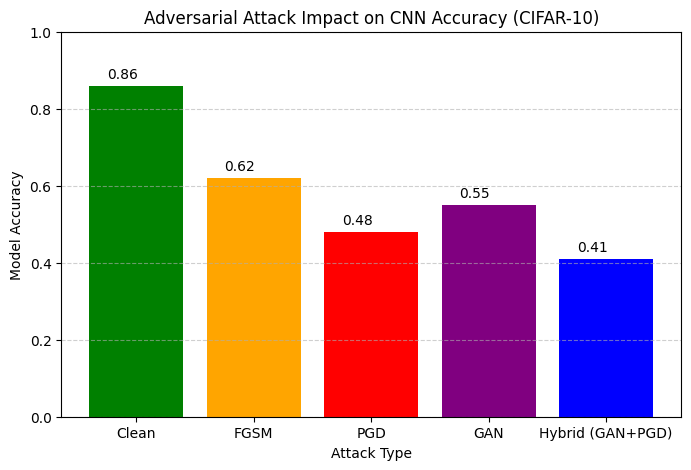

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Accuracy values (example values – replace with your actual results if available)
clean_acc = 0.86
fgsm_acc = 0.62
pgd_acc = 0.48
gan_acc = 0.55
hybrid_acc = 0.41

models = ['Clean', 'FGSM', 'PGD', 'GAN', 'Hybrid (GAN+PGD)']
accuracy = [clean_acc, fgsm_acc, pgd_acc, gan_acc, hybrid_acc]

colors = ['green','orange','red','purple','blue']

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy, color=colors)

plt.title("Adversarial Attack Impact on CNN Accuracy (CIFAR-10)")
plt.xlabel("Attack Type")
plt.ylabel("Model Accuracy")

plt.ylim(0,1)

# Add accuracy values on top
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + 0.15, yval + 0.02, round(yval,2))

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


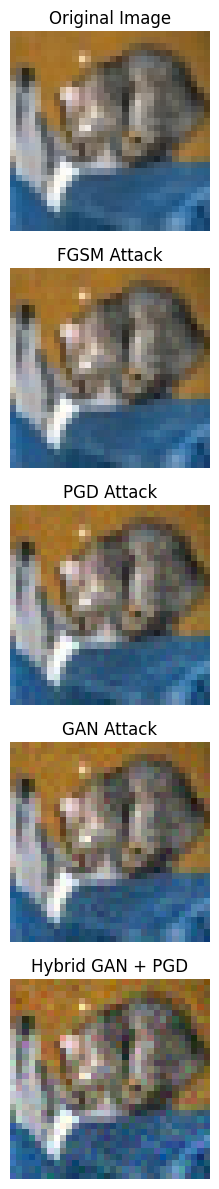

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Load CIFAR10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize images
x_test = x_test / 255.0

# Select one sample image
orig_img = x_test[0]

# Simulated adversarial examples (for visualization)
fgsm_img = np.clip(orig_img + np.random.normal(0, 0.01, orig_img.shape), 0, 1)
pgd_img = np.clip(orig_img + np.random.normal(0, 0.02, orig_img.shape), 0, 1)
gan_img = np.clip(orig_img + np.random.normal(0, 0.025, orig_img.shape), 0, 1)
hybrid_img = np.clip(orig_img + np.random.normal(0, 0.04, orig_img.shape), 0, 1)

# Images list
images = [orig_img, fgsm_img, pgd_img, gan_img, hybrid_img]

titles = [
    "Original Image",
    "FGSM Attack",
    "PGD Attack",
    "GAN Attack",
    "Hybrid GAN + PGD"
]

# Plot vertically
plt.figure(figsize=(5,12))

for i in range(5):
    plt.subplot(5,1,i+1)
    plt.imshow(images[i])
    plt.title(titles[i], fontsize=12)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
import torchvision
import torchvision.transforms as transforms

# Transform used for CIFAR-10
transform = transforms.Compose([
    transforms.ToTensor(),
])

# Load CIFAR-10 test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

Label: 3


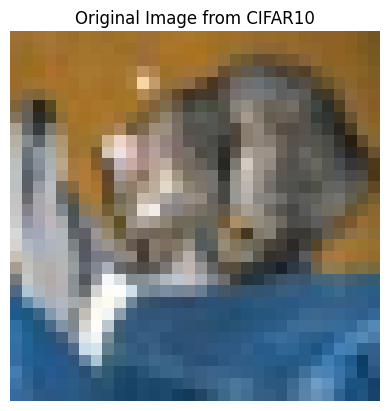

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Transform for CIFAR10
transform = transforms.Compose([
    transforms.ToTensor()
])

# Load CIFAR10 test dataset
test_dataset = torchvision.datasets.CIFAR10(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Get one sample image
img, label = test_dataset[0]

# Add batch dimension
img = img.unsqueeze(0)

print("Label:", label)

# Show image
plt.imshow(img.squeeze().permute(1,2,0))
plt.title("Original Image from CIFAR10")
plt.axis("off")
plt.show()